# GaussED

In [1]:
import jax
from jax import config
import jax.numpy as jnp
from jax import Array
import numpy as np
config.update("jax_enable_x64", True)  # do this at the very top

import matplotlib.pyplot as plt

import mplcyberpunk
plt.style.use("cyberpunk")

plt.rcParams["figure.figsize"] = (5, 3)
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]  # matches LaTeX default


from gaussed.domains import Euclidean
from gaussed.domains.index import IndexDomain
from gaussed.codomains import Codomain

from gaussed.gp.gp_ops.base import KernelSpec, FunSpec
from gaussed.gp.gp_ops.point_eval import Eval
from gaussed.gp.gp_ops.partial import Partial
from gaussed.gp.gp_ops.grad import Grad
from gaussed.gp.gp_ops.affine import Affine
from gaussed.gp.gp_ops.weighted_eval import WeightedEval
from gaussed.gp.gp_ops.probe import Probe, ProbeStack, as_stack
from gaussed.gp.gp_ops.linearise import Linearise

from gaussed.gp.kernels.rbf import RBFKernel, RBFParams
from gaussed.gp.kernels.matern import MaternKernel, MaternParams
from gaussed.gp.kernels.imq import IMQKernel, IMQParams
from gaussed.gp.kernels.delta import DeltaKernel, DeltaParams
from gaussed.gp.kernels.stacked import StackedKernel
from gaussed.gp.kernels.coregional import CoregionParams, CoregionalKernel
from gaussed.gp.means import ZeroMeanFun
from gaussed.gp.base import GP, PosteriorGP

from gaussed.model import GPModel
from gaussed.utils.shape_helpers import pack_ev2mat

from gaussed.backends.base import ExactBackend
from gaussed.backends.solvers.linear_solver import SolverFns
from gaussed.backends.solvers.cholesky import (
    chol_solve_hook,
    chol_sqrt_hook,
    chol_logdet_hook,
)
from gaussed.backends.solvers.svd import svd_solve_hook, svd_sqrt_hook, svd_logdet_hook

from gaussed.likelihoods.gaussian import GaussianLikelihood
from gaussed.likelihoods.gaussian_noise import DiagonalNoise
from gaussed.sed.base import *

solver_fns = SolverFns(svd_solve_hook(), svd_sqrt_hook(), svd_logdet_hook())


## Gradient Operator

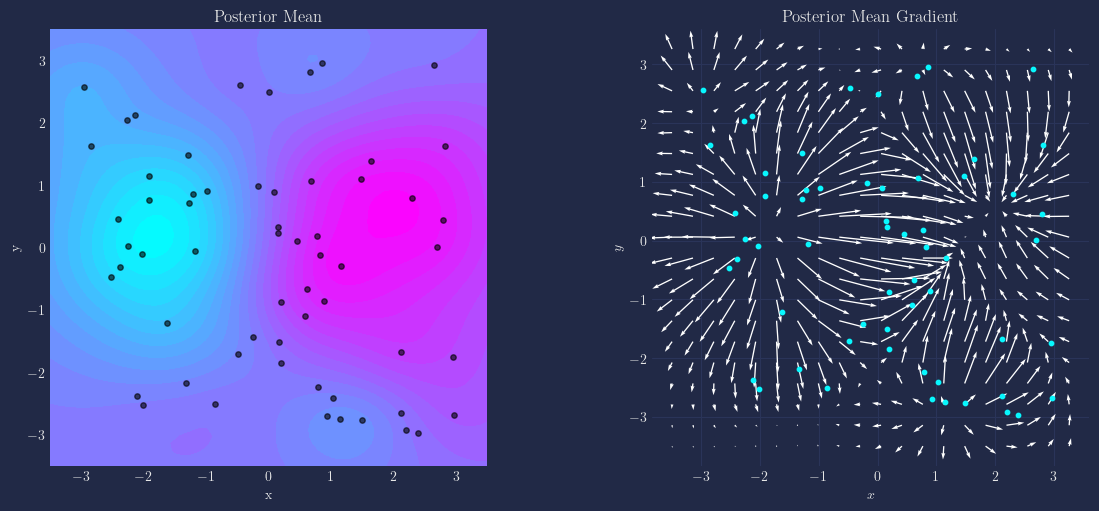

In [4]:
# ----------------------------
# GP prior (2D, with ARD)
# ----------------------------
domain   = Euclidean((2,))
codomain = Codomain((1,))
mean     = ZeroMeanFun(domain, codomain)

solver_fns = SolverFns(chol_solve_hook(), chol_sqrt_hook(), chol_logdet_hook())

backend = ExactBackend(solverfns=solver_fns)

# ARD lengthscales (ℓ_x, ℓ_y); amplitude = σ²
imq_params = IMQParams(
    lengthscale=jnp.array([1.0, 0.7]),  # ARD
    amplitude=jnp.array(1.0),
    beta=jnp.array(1.0),
)
kernel  = IMQKernel(imq_params)

gp      = GP(domain, codomain, mean, kernel, backend)

# ----------------------------
# Synthetic 2D data
# ----------------------------
key = jax.random.PRNGKey(0)
n_tr = 60
Xtr = jax.random.uniform(key, (n_tr, 2), minval=-3.0, maxval=3.0)

def f_true(xy: jnp.ndarray) -> jnp.ndarray:
    # smooth, non-separable target
    x, y = xy[..., 0], xy[..., 1]
    return jnp.sin(x) * jnp.cos(0.8 * y) + 0.2 * x

y_clean = jax.vmap(f_true)(Xtr)
noise   = 0.1
y       = y_clean + noise * jax.random.normal(key, shape=y_clean.shape)

# ----------------------------
# Probes
# ----------------------------
Ftr   = Probe(ops=(), fnl=Eval(Xtr))                 # function values at Xtr
lik   = GaussianLikelihood(noise=DiagonalNoise(jnp.array([0.01])))
model = GPModel(gp=gp, likelihood=lik)
post  = model.condition(Ftr, y)

# Test grid for visualisation
nx = ny = 60
x1 = jnp.linspace(-3.5, 3.5, nx)
x2 = jnp.linspace(-3.5, 3.5, ny)
Xg1, Xg2 = jnp.meshgrid(x1, x2, indexing="xy")
Xgrid = jnp.stack([Xg1.ravel(), Xg2.ravel()], axis=1)     # (nx*ny, 2)

F_eval  = Probe(ops=(), fnl=Eval(Xgrid))                  # function probe
F_grad  = Probe(ops=(Grad(), ), fnl=Eval(Xgrid))  # gradient probe (∂/∂x, ∂/∂y)

# Posterior mean and gradient mean
m_post_grid = post.mean(F_eval).reshape(nx*ny)            # (N,)
g_post_grid = post.mean(F_grad).reshape(nx*ny, 2)         # (N, 2)

# ----------------------------
# Autodiff cross-check of gradient
# ----------------------------
# Make a scalar-valued mean function m(x) using the same machinery,
# then compare ∇m(x) from autodiff with the Gradient probe output.
def mean_at(x_row: jnp.ndarray) -> jnp.ndarray:
    Fe = Probe(ops=(), fnl=Eval(x_row[None, :]))
    return post.mean(Fe).squeeze()                        # scalar

grad_mean_at = jax.jit(jax.grad(mean_at))                 # (2,) -> (2,)

# # Check on a small random subset to keep it snappy
# idx = jnp.arange(Xgrid.shape[0])[:: max(1, (nx*ny)//2000)]
# Xchk = Xgrid[idx]
# g_ad  = jax.vmap(grad_mean_at)(Xchk)                      # (M, 2)
# g_gp  = g_post_grid[idx]                                  # (M, 2)
# grad_max_err = jnp.max(jnp.abs(g_ad - g_gp))
# print("Max |∇ mean| error vs autodiff:", float(grad_max_err))

# ----------------------------
# Plotting (two separate figures)
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# 1) Posterior mean as filled contours
ax = axes[0]
M = m_post_grid.reshape(ny, nx)
cf = ax.contourf(Xg1, Xg2, M, levels=25)
ax.scatter(np.array(Xtr[:, 0]), np.array(Xtr[:, 1]), s=15, c="k", alpha=0.6)
ax.set_title("Posterior Mean")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", adjustable="box")

# 2) Gradient quiver (posterior mean gradient)
ax = axes[1]
G = g_post_grid.reshape(ny, nx, 2)
step = max(1, nx // 20)  # thin arrows for clarity
ax.quiver(
    Xg1[::step, ::step], Xg2[::step, ::step],
    G[::step, ::step, 0], G[::step, ::step, 1],
    angles="xy", scale_units="xy", scale=1.0, color='white'
)
ax.scatter(Xtr[:, 0], Xtr[:, 1], s=10)
ax.set_title("Posterior Mean Gradient")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_aspect("equal", adjustable="box")

plt.show()


In [21]:
from gaussed.backends.base import BasisBackend
from gaussed.backends.basis.spectral_basis import LaplaceBasis

from gaussed.gp.means import ZeroMeanFun

In [22]:
import jax
from jax import config
import jax.numpy as jnp
from jax import Array
import numpy as np
config.update("jax_enable_x64", True)  # do this at the very top

from gaussed.gp.kernels.matern import MaternKernel, MaternParams
from gaussed.backends.base import BasisBackend

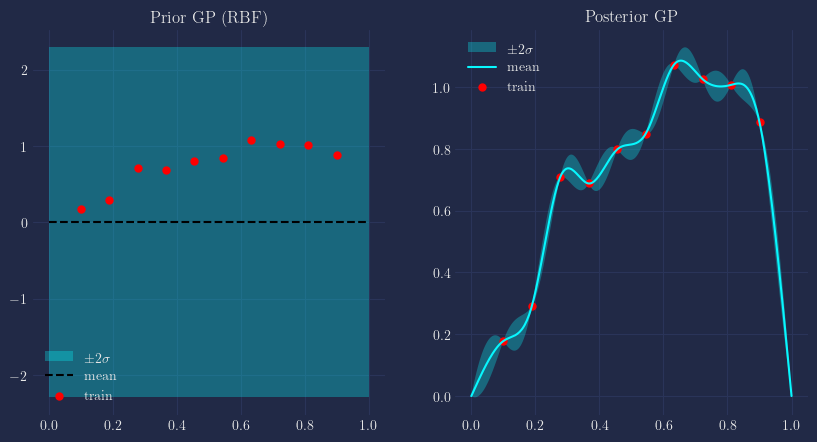

In [23]:
# --- GP prior ---
domain   = Euclidean((1,))
codomain = Codomain((1,))
basis = LaplaceBasis(1)
mean     = ZeroMeanFun(domain, codomain)
matern_params = MaternParams(lengthscale=jnp.array(0.), amplitude=jnp.array(1.0), nu=1.5)
kernel   = MaternKernel(matern_params)
backend = BasisBackend(solverfns=solver_fns, basis_family=basis, m_per_dim=100) 

gp = GP(domain, codomain, mean, kernel, backend)

# --- Data ---
key = jax.random.PRNGKey(0)
Xtr = jnp.linspace(0.1, 0.9, 10).reshape(-1, 1)
y_clean = jnp.sin(2 * Xtr).squeeze()
noise = 0.1
y = y_clean + noise * jax.random.normal(key, shape=y_clean.shape)

# --- Probes ---
Ftr = Probe(ops=(), fnl=Eval(Xtr))
Xt = jnp.linspace(0.0, 1.0, 300).reshape(-1, 1)
Fte = Probe(ops=(), fnl=Eval(Xt))

# --- Model / condition ---
lik = GaussianLikelihood()
model = GPModel(gp=gp, likelihood=lik)
post = model.condition(Ftr, y)

# --- Prior mean/var (for reference) ---
prior_mean = gp.mean_spec().eval(Xt)[:, 0]
prior_var  = jnp.diag(pack_ev2mat(gp.kernel_spec().k0(Xt, Xt), (1,), (1,)))

# --- Posterior mean/var ---
m_post = post.mean(Fte)
v_post = post.variance(Fte)

# --- Plot ---
xplot = Xt.squeeze()

plt.figure(figsize=(10,5))

# Prior
plt.subplot(1,2,1)
plt.title("Prior GP (RBF)")
plt.fill_between(xplot,
                 prior_mean - 2*jnp.sqrt(prior_var),
                 prior_mean + 2*jnp.sqrt(prior_var),
                 alpha=0.3, label="$\\pm 2 \\sigma$")
plt.plot(xplot, prior_mean, "k--", label="mean")
plt.scatter(Xtr.squeeze(), y, s=25, c="r", label="train")
plt.legend()

# Posterior
plt.subplot(1,2,2)
plt.title("Posterior GP")
plt.fill_between(xplot,
                 m_post.reshape(-1,) - 2*jnp.sqrt(v_post),
                 m_post.reshape(-1,) + 2*jnp.sqrt(v_post),
                 alpha=0.3, label="$\\pm2\\sigma$")
plt.plot(xplot, m_post, label="mean")
plt.scatter(Xtr.squeeze(), y, s=25, c="r", label="train")
plt.legend()

# plt.tight_layout()
plt.show()


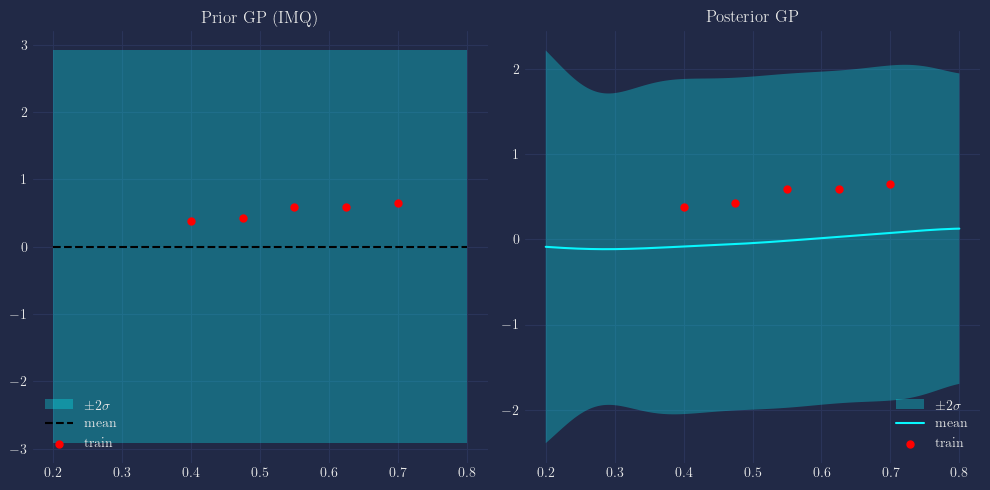

In [65]:

# --- GP prior ---
domain   = Euclidean((1,))
codomain = Codomain((1,))
basis = LaplaceBasis(1)
mean     = ZeroMeanFun(domain, codomain)
rbf_params = RBFParams(lengthscale=jnp.array(-2), amplitude=jnp.array(2.0))
kernel   = RBFKernel(rbf_params)
backend = BasisBackend(solverfns=solver_fns, basis_family=basis, m_per_dim=100) 

gp = GP(domain, codomain, mean, kernel, backend)


# --- Data ---
key = jax.random.PRNGKey(0)
Xtr = jnp.linspace(0.4, 0.7, 5).reshape(-1, 1)
y_clean = jnp.sin(Xtr).squeeze()
noise = 0.04
y = y_clean + noise * jax.random.normal(key, shape=y_clean.shape)

# --- Probes ---
Ftr = Probe(ops=(Partial(0),), fnl=Eval(Xtr))
Xt = jnp.linspace(0.2, 0.8, 300).reshape(-1, 1)
Fte = Probe(ops=(), fnl=Eval(Xt))

# --- Model / condition ---
lik = GaussianLikelihood(noise=DiagonalNoise(jnp.array([-3.])))
model = GPModel(gp=gp, likelihood=lik)
post = model.condition(Ftr, y)

# --- Prior mean/var (for reference) ---
prior_mean = gp.mean_spec().eval(Xt)[:, 0]
prior_var  = jnp.diag(pack_ev2mat(gp.kernel_spec().k0(Xt, Xt), (1,), (1,)))

# --- Posterior mean/var ---
m_post = post.mean(Fte)
v_post = post.variance(Fte)

# --- Plot ---
xplot = Xt.squeeze()

plt.figure(figsize=(10,5))

# Prior
plt.subplot(1,2,1)
plt.title("Prior GP (IMQ)")
plt.fill_between(xplot,
                 prior_mean - 2*jnp.sqrt(prior_var),
                 prior_mean + 2*jnp.sqrt(prior_var),
                 alpha=0.3, label="$\\pm 2 \\sigma$")
plt.plot(xplot, prior_mean, "k--", label="mean")
plt.scatter(Xtr.squeeze(), y, s=25, c="r", label="train")
plt.legend()

# Posterior
plt.subplot(1,2,2)
plt.title("Posterior GP")
plt.fill_between(xplot,
                 m_post.reshape(-1,) - 2*jnp.sqrt(v_post),
                 m_post.reshape(-1,) + 2*jnp.sqrt(v_post),
                 alpha=0.3, label="$\\pm2\\sigma$")
plt.plot(xplot, m_post, label="mean")
plt.scatter(Xtr.squeeze(), y, s=25, c="r", label="train")
plt.legend()

plt.tight_layout()
plt.show()


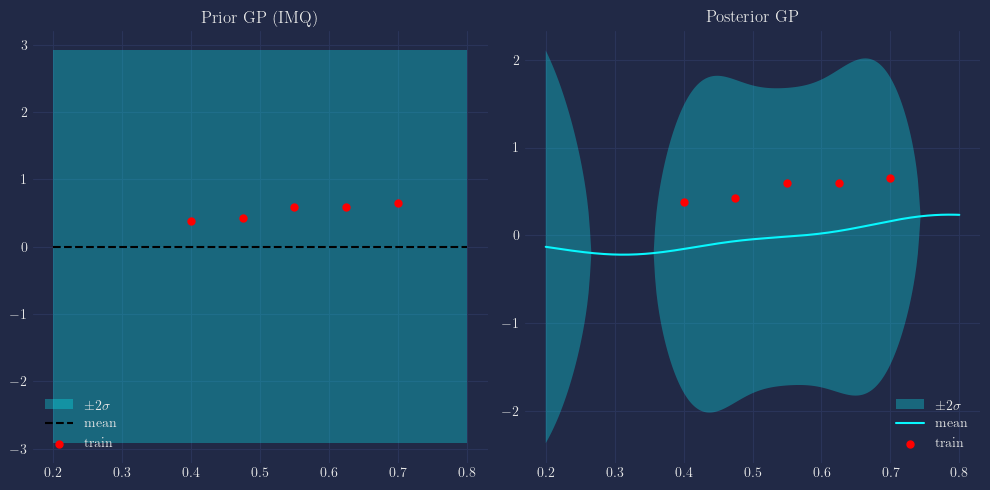

In [66]:

# --- GP prior ---
domain   = Euclidean((1,))
codomain = Codomain((1,))
mean     = ZeroMeanFun(domain, codomain)
rbf_params = RBFParams(lengthscale=jnp.array(-2), amplitude=jnp.array(2.0))
kernel   = RBFKernel(rbf_params)
backend = ExactBackend(solverfns=solver_fns)

gp = GP(domain, codomain, mean, kernel, backend)


# --- Data ---
key = jax.random.PRNGKey(0)
Xtr = jnp.linspace(0.4, 0.7, 5).reshape(-1, 1)
y_clean = jnp.sin(Xtr).squeeze()
noise = 0.04
y = y_clean + noise * jax.random.normal(key, shape=y_clean.shape)

# --- Probes ---
Ftr = Probe(ops=(Partial(0),), fnl=Eval(Xtr))
Xt = jnp.linspace(0.2, 0.8, 300).reshape(-1, 1)
Fte = Probe(ops=(), fnl=Eval(Xt))

# --- Model / condition ---
lik = GaussianLikelihood(noise=DiagonalNoise(jnp.array([-3.])))
model = GPModel(gp=gp, likelihood=lik)
post = model.condition(Ftr, y)

# --- Prior mean/var (for reference) ---
prior_mean = gp.mean_spec().eval(Xt)[:, 0]
prior_var  = jnp.diag(pack_ev2mat(gp.kernel_spec().k0(Xt, Xt), (1,), (1,)))

# --- Posterior mean/var ---
m_post = post.mean(Fte)
v_post = post.variance(Fte)

# --- Plot ---
xplot = Xt.squeeze()

plt.figure(figsize=(10,5))

# Prior
plt.subplot(1,2,1)
plt.title("Prior GP (IMQ)")
plt.fill_between(xplot,
                 prior_mean - 2*jnp.sqrt(prior_var),
                 prior_mean + 2*jnp.sqrt(prior_var),
                 alpha=0.3, label="$\\pm 2 \\sigma$")
plt.plot(xplot, prior_mean, "k--", label="mean")
plt.scatter(Xtr.squeeze(), y, s=25, c="r", label="train")
plt.legend()

# Posterior
plt.subplot(1,2,2)
plt.title("Posterior GP")
plt.fill_between(xplot,
                 m_post.reshape(-1,) - 2*jnp.sqrt(v_post),
                 m_post.reshape(-1,) + 2*jnp.sqrt(v_post),
                 alpha=0.3, label="$\\pm2\\sigma$")
plt.plot(xplot, m_post, label="mean")
plt.scatter(Xtr.squeeze(), y, s=25, c="r", label="train")
plt.legend()

plt.tight_layout()
plt.show()


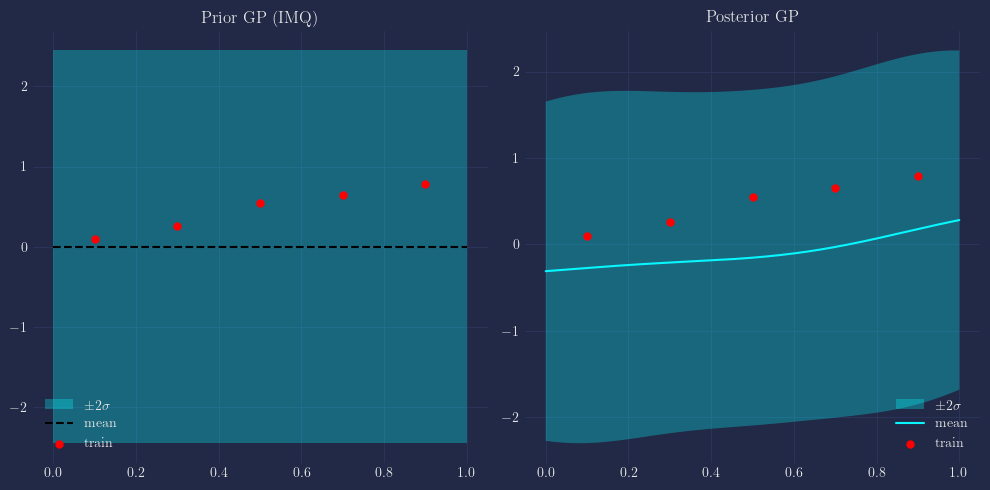

In [33]:

# --- GP prior ---
domain   = Euclidean((1,))
codomain = Codomain((1,))
mean     = ZeroMeanFun(domain, codomain)
matern_params = MaternParams(lengthscale=jnp.array(-2.), amplitude=jnp.array(3.), nu=1.5)
kernel   = MaternKernel(matern_params)
backend = ExactBackend(solverfns=solver_fns)

gp = GP(domain, codomain, mean, imq_kernel, backend)

# --- Data ---
key = jax.random.PRNGKey(0)
Xtr = jnp.linspace(0.1, 0.9, 5).reshape(-1, 1)
y_clean = jnp.sin(Xtr).squeeze()
noise = 0.04
y = y_clean + noise * jax.random.normal(key, shape=y_clean.shape)

# --- Probes ---
Ftr = Probe(ops=(Partial(0),), fnl=Eval(Xtr))
Xt = jnp.linspace(0, 1., 300).reshape(-1, 1)
Fte = Probe(ops=(), fnl=Eval(Xt))

# --- Model / condition ---
lik = GaussianLikelihood(noise=DiagonalNoise(jnp.array([0.01])))
model = GPModel(gp=gp, likelihood=lik)
post = model.condition(Ftr, y)

# --- Prior mean/var (for reference) ---
prior_mean = gp.mean_spec().eval(Xt)[:, 0]
prior_var  = jnp.diag(pack_ev2mat(gp.kernel_spec().k0(Xt, Xt), (1,), (1,)))

# --- Posterior mean/var ---
m_post = post.mean(Fte)
v_post = post.variance(Fte)

# --- Plot ---
xplot = Xt.squeeze()

plt.figure(figsize=(10,5))

# Prior
plt.subplot(1,2,1)
plt.title("Prior GP (IMQ)")
plt.fill_between(xplot,
                 prior_mean - 2*jnp.sqrt(prior_var),
                 prior_mean + 2*jnp.sqrt(prior_var),
                 alpha=0.3, label="$\\pm 2 \\sigma$")
plt.plot(xplot, prior_mean, "k--", label="mean")
plt.scatter(Xtr.squeeze(), y, s=25, c="r", label="train")
plt.legend()

# Posterior
plt.subplot(1,2,2)
plt.title("Posterior GP")
plt.fill_between(xplot,
                 m_post.reshape(-1,) - 2*jnp.sqrt(v_post),
                 m_post.reshape(-1,) + 2*jnp.sqrt(v_post),
                 alpha=0.3, label="$\\pm2\\sigma$")
plt.plot(xplot, m_post, label="mean")
plt.scatter(Xtr.squeeze(), y, s=25, c="r", label="train")
plt.legend()

plt.tight_layout()
plt.show()


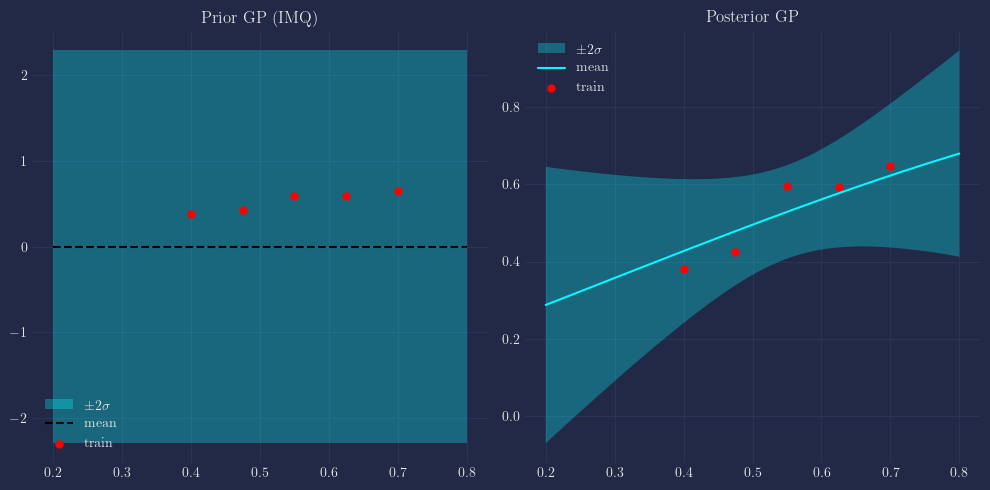

In [53]:

# --- GP prior ---
domain   = Euclidean((1,))
codomain = Codomain((1,))
mean     = ZeroMeanFun(domain, codomain)
rbf_params = RBFParams(lengthscale=jnp.array(1.), amplitude=jnp.array(1.0))
kernel   = RBFKernel(rbf_params)
backend = ExactBackend(solverfns=solver_fns)

gp = GP(domain, codomain, mean, kernel, backend)


# --- Data ---
key = jax.random.PRNGKey(0)
Xtr = jnp.linspace(0.4, 0.7, 5).reshape(-1, 1)
y_clean = jnp.sin(Xtr).squeeze()
noise = 0.04
y = y_clean + noise * jax.random.normal(key, shape=y_clean.shape)

# --- Probes ---
Ftr = Probe(ops=(), fnl=Eval(Xtr))
Xt = jnp.linspace(0.2, 0.8, 300).reshape(-1, 1)
Fte = Probe(ops=(), fnl=Eval(Xt))

# --- Model / condition ---
lik = GaussianLikelihood(noise=DiagonalNoise(jnp.array([-4.])))
model = GPModel(gp=gp, likelihood=lik)
post = model.condition(Ftr, y)

# --- Prior mean/var (for reference) ---
prior_mean = gp.mean_spec().eval(Xt)[:, 0]
prior_var  = jnp.diag(pack_ev2mat(gp.kernel_spec().k0(Xt, Xt), (1,), (1,)))

# --- Posterior mean/var ---
m_post = post.mean(Fte)
v_post = post.variance(Fte)

# --- Plot ---
xplot = Xt.squeeze()

plt.figure(figsize=(10,5))

# Prior
plt.subplot(1,2,1)
plt.title("Prior GP (IMQ)")
plt.fill_between(xplot,
                 prior_mean - 2*jnp.sqrt(prior_var),
                 prior_mean + 2*jnp.sqrt(prior_var),
                 alpha=0.3, label="$\\pm 2 \\sigma$")
plt.plot(xplot, prior_mean, "k--", label="mean")
plt.scatter(Xtr.squeeze(), y, s=25, c="r", label="train")
plt.legend()

# Posterior
plt.subplot(1,2,2)
plt.title("Posterior GP")
plt.fill_between(xplot,
                 m_post.reshape(-1,) - 2*jnp.sqrt(v_post),
                 m_post.reshape(-1,) + 2*jnp.sqrt(v_post),
                 alpha=0.3, label="$\\pm2\\sigma$")
plt.plot(xplot, m_post, label="mean")
plt.scatter(Xtr.squeeze(), y, s=25, c="r", label="train")
plt.legend()

plt.tight_layout()
plt.show()


In [58]:
test = GaussianLikelihood(noise=DiagonalNoise(jnp.array([-10.])))

test.noise.as_op(10, dtype=jnp.float64).to_dense()

Array([[4.53989002e-05, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 4.53989002e-05, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 4.53989002e-05, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 4.53989002e-05,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        4.53989002e-05, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
   